# 05 — Stacking Ensemble (Improved)
**Ensemble Early Parkinson Detection Using Voice Biomarkers**

This notebook implements an improved stacking ensemble with three key changes from the initial attempt:

1. **Common feature set (SVM-RFE)** for all base learners — simplifies stacking and reduces noise
2. **5 base learners** — adding Logistic_L2 (our best individual model)
3. **Enriched meta-features** — probabilities + hard predictions + confidence margins (15 features instead of 5)
4. **Class-weighted meta-learner** — addresses the 3:1 imbalance at the meta-level

| Level-0 Base Learner | Family | Tuned Hyperparameters |
|---|---|---|
| SVM_RBF | Kernel | C=100, gamma=0.001 |
| KNN | Instance-based | k=15, uniform, euclidean |
| Random Forest | Tree Ensemble | max_depth=3, 50 trees |
| Logistic L1 | Linear (sparse) | C=1 |
| Logistic L2 | Linear (ridge) | C=0.1 |

All base learners use SVM-RFE features (10 features) with `class_weight='balanced'` where supported.

**Level-1 Meta-learner:** Logistic Regression (L2, `class_weight='balanced'`)

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from imblearn.pipeline import Pipeline as ImbPipeline

from src.data_utils import load_parkinsons, get_X_y_groups, FEATURE_COLS
from src.eval_utils import (
    compute_metrics, results_to_dataframe, plot_confusion_matrix
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
N_OUTER = 5
N_INNER = 5

df = load_parkinsons()
X, y, groups = get_X_y_groups(df)
print(f'X: {X.shape}, y: {y.shape}, Subjects: {groups.nunique()}')

X: (195, 22), y: (195,), Subjects: 32


## 2. Define Base Learners — Common Feature Set

In [2]:
# Common feature set: SVM-RFE (dominated in NB03 for 4 of 6 models)
SVM_RFE_FEATURES = [
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ',
    'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE'
]

# Common feature matrix for all base learners
X_common = X[SVM_RFE_FEATURES]
print(f'Common feature set: {len(SVM_RFE_FEATURES)} features')
print(f'Features: {SVM_RFE_FEATURES}')

# 5 base learners with tuned hyperparameters from NB04
BASE_LEARNERS = {
    'SVM_RBF': SVC(
        kernel='rbf', C=100, gamma=0.001, class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=15, weights='uniform', metric='euclidean'
    ),
    'Random_Forest': RandomForestClassifier(
        n_estimators=50, max_depth=3, min_samples_split=10,
        min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L1': LogisticRegression(
        penalty='l1', C=1, solver='saga', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L2': LogisticRegression(
        penalty='l2', C=0.1, solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}

# Class-weighted meta-learner
META_LEARNER = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=5000,
    class_weight='balanced', random_state=RANDOM_STATE
)

print(f'\nBase learners ({len(BASE_LEARNERS)}): {list(BASE_LEARNERS.keys())}')
print(f'Meta-learner: Logistic Regression (L2, C=1.0, class_weight=balanced)')

Common feature set: 10 features
Features: ['MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ', 'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE']

Base learners (5): ['SVM_RBF', 'KNN', 'Random_Forest', 'Logistic_L1', 'Logistic_L2']
Meta-learner: Logistic Regression (L2, C=1.0, class_weight=balanced)


## 3. Enriched Meta-Feature Generation

For each base learner, we generate **three** types of meta-features:
1. **Probability** of PD (class 1) — continuous confidence estimate
2. **Hard prediction** (0 or 1) — binary vote
3. **Confidence margin** = |P(PD) - 0.5| — how certain the model is

This gives us 5 × 3 = 15 meta-features instead of 5, providing the meta-learner with richer information about each base learner's behavior.

In [3]:
def build_base_pipeline(clf):
    """Wrap a classifier in a StandardScaler pipeline."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])


def get_enriched_meta_features(pipe, X_data):
    """
    Generate enriched meta-features from a fitted pipeline:
    [probability, hard_prediction, confidence_margin]
    """
    if hasattr(pipe, 'predict_proba'):
        proba = pipe.predict_proba(X_data)[:, 1]
    else:
        proba = pipe.predict(X_data).astype(float)
    
    hard_pred = pipe.predict(X_data).astype(float)
    confidence = np.abs(proba - 0.5)
    
    return proba, hard_pred, confidence


def generate_enriched_oof(base_learners, X_feat, y, groups, n_splits=5):
    """
    Generate enriched out-of-fold meta-features for all base learners.
    
    Returns:
        meta_X: np.array of shape (n_samples, n_models * 3)
        meta_y: np.array of shape (n_samples,)
        feature_names: list of meta-feature names
    """
    n_samples = len(y)
    n_models = len(base_learners)
    
    # 3 meta-features per model: probability, hard_pred, confidence
    meta_X = np.zeros((n_samples, n_models * 3))
    
    inner_cv = GroupKFold(n_splits=n_splits)
    
    for model_idx, (name, clf) in enumerate(base_learners.items()):
        for train_idx, val_idx in inner_cv.split(X_feat, y, groups):
            pipe = build_base_pipeline(clone(clf))
            
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                pipe.fit(X_feat.iloc[train_idx], y.iloc[train_idx])
            
            proba, hard_pred, confidence = get_enriched_meta_features(
                pipe, X_feat.iloc[val_idx]
            )
            
            col_base = model_idx * 3
            meta_X[val_idx, col_base] = proba
            meta_X[val_idx, col_base + 1] = hard_pred
            meta_X[val_idx, col_base + 2] = confidence
    
    feature_names = []
    for name in base_learners.keys():
        feature_names.extend([f'{name}_prob', f'{name}_pred', f'{name}_conf'])
    
    return meta_X, y.values, feature_names


def train_and_predict_enriched(base_learners, X_train, y_train, X_test):
    """
    Train all base learners on full training set and generate
    enriched meta-features for the test set.
    """
    n_test = len(X_test)
    n_models = len(base_learners)
    meta_X_test = np.zeros((n_test, n_models * 3))
    
    fitted_pipelines = {}
    
    for model_idx, (name, clf) in enumerate(base_learners.items()):
        pipe = build_base_pipeline(clone(clf))
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            pipe.fit(X_train, y_train)
        
        fitted_pipelines[name] = pipe
        
        proba, hard_pred, confidence = get_enriched_meta_features(pipe, X_test)
        
        col_base = model_idx * 3
        meta_X_test[:, col_base] = proba
        meta_X_test[:, col_base + 1] = hard_pred
        meta_X_test[:, col_base + 2] = confidence
    
    return meta_X_test, fitted_pipelines


print('Enriched stacking helper functions defined.')
print(f'Meta-features per model: probability, hard_prediction, confidence_margin')
print(f'Total meta-features: {len(BASE_LEARNERS)} models × 3 = {len(BASE_LEARNERS) * 3}')

Enriched stacking helper functions defined.
Meta-features per model: probability, hard_prediction, confidence_margin
Total meta-features: 5 models × 3 = 15


## 4. Run Improved Stacking with Subject-wise Outer CV

In [4]:
outer_cv = GroupKFold(n_splits=N_OUTER)

# Storage
stack_y_trues = []
stack_y_preds = []
stack_y_probs = []
stack_fold_metrics = []
meta_weights_per_fold = []
meta_feature_names = None

# Track base learner predictions for comparison
base_y_preds = {name: [] for name in BASE_LEARNERS}
base_y_trues = {name: [] for name in BASE_LEARNERS}

print('Running IMPROVED stacking ensemble...\n')

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_common, y, groups)):
    print(f'--- Outer Fold {fold_idx + 1} ---')
    
    X_train = X_common.iloc[train_idx]
    X_test = X_common.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]
    
    n_pd = int(y_test.sum())
    n_healthy = int((y_test == 0).sum())
    print(f'  Train: {len(y_train)}, Test: {len(y_test)} (PD={n_pd}, Healthy={n_healthy})')
    
    # Step 1: Generate enriched OOF predictions on training set
    meta_X_train, meta_y_train, meta_feature_names = generate_enriched_oof(
        BASE_LEARNERS, X_train, y_train, groups_train, n_splits=N_INNER
    )
    print(f'  Meta-features (train): {meta_X_train.shape}')
    
    # Step 2: Train class-weighted meta-learner
    meta = clone(META_LEARNER)
    meta.fit(meta_X_train, meta_y_train)
    meta_weights_per_fold.append(meta.coef_[0])
    
    # Step 3: Train base learners on full training set + predict test meta-features
    meta_X_test, fitted_pipes = train_and_predict_enriched(
        BASE_LEARNERS, X_train, y_train, X_test
    )
    
    # Step 4: Meta-learner predicts
    y_pred_stack = meta.predict(meta_X_test)
    y_prob_stack = meta.predict_proba(meta_X_test)[:, 1]
    
    stack_y_trues.append(y_test.values)
    stack_y_preds.append(y_pred_stack)
    stack_y_probs.append(y_prob_stack)
    stack_fold_metrics.append(compute_metrics(y_test, y_pred_stack, y_prob_stack))
    
    # Track individual base learner predictions
    for name, pipe in fitted_pipes.items():
        base_y_preds[name].append(pipe.predict(X_test))
        base_y_trues[name].append(y_test.values)
    
    fm = stack_fold_metrics[-1]
    print(f'  Stacking BA: {fm["balanced_accuracy"]:.4f}, '
          f'Sens: {fm["sensitivity"]:.4f}, Spec: {fm["specificity"]:.4f}')
    print()

print('Improved stacking ensemble complete!')

Running IMPROVED stacking ensemble...

--- Outer Fold 1 ---
  Train: 158, Test: 37 (PD=31, Healthy=6)
  Meta-features (train): (158, 15)
  Stacking BA: 0.8871, Sens: 0.7742, Spec: 1.0000

--- Outer Fold 2 ---
  Train: 158, Test: 37 (PD=25, Healthy=12)
  Meta-features (train): (158, 15)
  Stacking BA: 0.7733, Sens: 0.8800, Spec: 0.6667

--- Outer Fold 3 ---
  Train: 158, Test: 37 (PD=31, Healthy=6)
  Meta-features (train): (158, 15)
  Stacking BA: 0.5188, Sens: 0.8710, Spec: 0.1667

--- Outer Fold 4 ---
  Train: 153, Test: 42 (PD=30, Healthy=12)
  Meta-features (train): (153, 15)
  Stacking BA: 0.6667, Sens: 0.6667, Spec: 0.6667

--- Outer Fold 5 ---
  Train: 153, Test: 42 (PD=30, Healthy=12)
  Meta-features (train): (153, 15)
  Stacking BA: 0.6583, Sens: 0.9000, Spec: 0.4167

Improved stacking ensemble complete!


## 5. Stacking Results

In [5]:
# Aggregate stacking metrics
stack_metrics_df = pd.DataFrame(stack_fold_metrics)
stack_mean = stack_metrics_df.mean()
stack_std = stack_metrics_df.std()

print('=== IMPROVED Stacking Ensemble Results (Subject-wise 5-Fold CV) ===\n')
for metric in ['balanced_accuracy', 'sensitivity', 'specificity', 'accuracy',
               'precision', 'f1', 'mcc', 'auc_roc']:
    print(f'  {metric:>20s}: {stack_mean[metric]:.4f} ± {stack_std[metric]:.4f}')

per_fold_ba = [round(m['balanced_accuracy'], 4) for m in stack_fold_metrics]
print(f'\nPer-fold balanced accuracy: {per_fold_ba}')

=== IMPROVED Stacking Ensemble Results (Subject-wise 5-Fold CV) ===

     balanced_accuracy: 0.7008 ± 0.1379
           sensitivity: 0.8184 ± 0.0977
           specificity: 0.5833 ± 0.3118
              accuracy: 0.7614 ± 0.0589
             precision: 0.8635 ± 0.0791
                    f1: 0.8354 ± 0.0540
                   mcc: 0.3734 ± 0.2240
               auc_roc: 0.8175 ± 0.1196

Per-fold balanced accuracy: [0.8871, 0.7733, 0.5188, 0.6667, 0.6583]


## 6. Meta-Learner Weight Analysis

With enriched meta-features, the meta-learner has 15 coefficients. We can see which *types* of information (probability vs prediction vs confidence) it values most, and from which base learners.

In [6]:
# Meta-learner weights analysis
weights_df = pd.DataFrame(
    meta_weights_per_fold,
    columns=meta_feature_names,
    index=[f'Fold {i+1}' for i in range(N_OUTER)]
)
weights_df.loc['Mean'] = weights_df.mean()
weights_df.loc['Std'] = weights_df.iloc[:N_OUTER].std()

print('Meta-learner coefficients (mean across folds):\n')
mean_weights = weights_df.loc['Mean'].sort_values(key=abs, ascending=False)
for feat, val in mean_weights.items():
    print(f'  {feat:>25s}: {val:+.4f}')

Meta-learner coefficients (mean across folds):

           Logistic_L2_prob: +1.9970
           Logistic_L1_prob: +1.3394
           Logistic_L2_pred: +0.7544
         Random_Forest_prob: -0.7457
           Logistic_L1_conf: -0.5078
           Logistic_L1_pred: +0.5068
                   KNN_pred: -0.4964
                   KNN_conf: +0.4888
           Logistic_L2_conf: +0.3030
               SVM_RBF_conf: -0.2883
         Random_Forest_pred: -0.2660
                   KNN_prob: -0.2556
               SVM_RBF_prob: +0.1008
         Random_Forest_conf: -0.0756
               SVM_RBF_pred: -0.0108


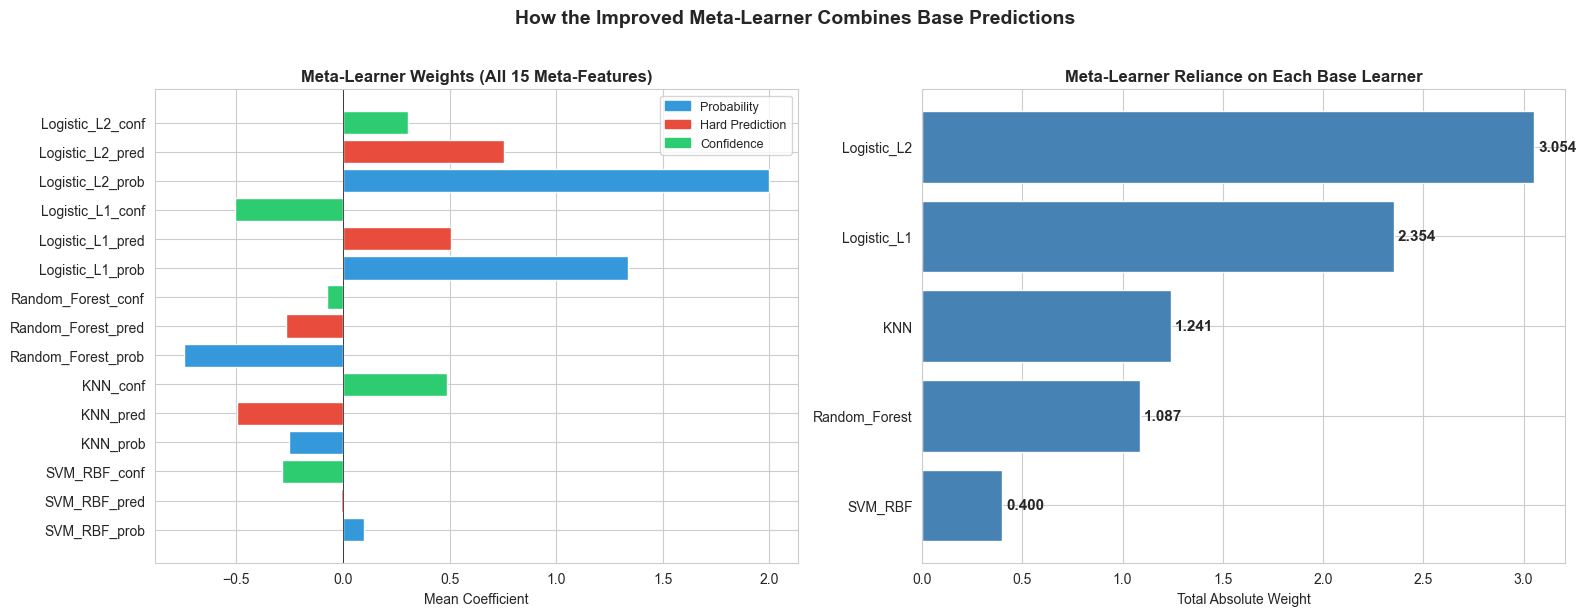

In [7]:
# Visualize mean weights grouped by base learner and feature type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of all 15 meta-feature weights
mean_w = weights_df.loc['Mean']
colors = []
for name in meta_feature_names:
    if '_prob' in name:
        colors.append('#3498db')
    elif '_pred' in name:
        colors.append('#e74c3c')
    else:
        colors.append('#2ecc71')

axes[0].barh(meta_feature_names, mean_w.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Mean Coefficient')
axes[0].set_title('Meta-Learner Weights (All 15 Meta-Features)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#3498db', label='Probability'),
    Patch(color='#e74c3c', label='Hard Prediction'),
    Patch(color='#2ecc71', label='Confidence'),
], fontsize=9)

# Aggregate weight magnitude by base learner
model_total_weight = {}
for name in BASE_LEARNERS.keys():
    model_feats = [f for f in meta_feature_names if f.startswith(name)]
    model_total_weight[name] = mean_w[model_feats].abs().sum()

model_w_series = pd.Series(model_total_weight).sort_values(ascending=True)
axes[1].barh(model_w_series.index, model_w_series.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Total Absolute Weight')
axes[1].set_title('Meta-Learner Reliance on Each Base Learner', fontsize=12, fontweight='bold')

for i, (name, val) in enumerate(model_w_series.items()):
    axes[1].text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('How the Improved Meta-Learner Combines Base Predictions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/improved_meta_learner_weights.png', bbox_inches='tight')
plt.show()

## 7. Stacking vs Individual Models Comparison

In [8]:
# Compute metrics for individual base learners (from same outer CV)
comparison = {}

# Stacking
all_yt_stack = np.concatenate(stack_y_trues)
all_yp_stack = np.concatenate(stack_y_preds)
all_yprob_stack = np.concatenate(stack_y_probs)
comparison['Stacking (Improved)'] = compute_metrics(all_yt_stack, all_yp_stack, all_yprob_stack)

# Individual base learners
for name in BASE_LEARNERS:
    all_yt = np.concatenate(base_y_trues[name])
    all_yp = np.concatenate(base_y_preds[name])
    comparison[name] = compute_metrics(all_yt, all_yp)

comp_df = results_to_dataframe(comparison)
print('--- Improved Stacking vs Individual Base Learners (Same Outer CV) ---\n')
print(comp_df.to_string())

--- Improved Stacking vs Individual Base Learners (Same Outer CV) ---

                     accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                         
Stacking (Improved)    0.7590             0.6998       0.8163       0.5833     0.8571  0.8362  0.3826   0.7868
SVM_RBF                0.7436             0.7317       0.7551       0.7083     0.8880  0.8162  0.4162      NaN
KNN                    0.8103             0.7128       0.9048       0.5208     0.8526  0.8779  0.4583      NaN
Random_Forest          0.7744             0.7170       0.8299       0.6042     0.8652  0.8472  0.4179      NaN
Logistic_L1            0.7795             0.7625       0.7959       0.7292     0.9000  0.8448  0.4798      NaN
Logistic_L2            0.7692             0.7838       0.7551       0.8125     0.9250  0.8315  0.5026      NaN


In [9]:
# Compare against NB04 tuned results and original stacking
nb04_results = pd.read_csv('../results/tuned_results.csv', index_col=0)

full_comparison = {}
full_comparison['Stacking (Improved)'] = stack_mean.to_dict()

# Load original stacking if available
try:
    orig_stack = pd.read_csv('../results/stacking_results.csv')
    orig_dict = dict(zip(orig_stack['metric'], orig_stack['mean']))
    full_comparison['Stacking (Original)'] = orig_dict
except FileNotFoundError:
    pass

for model_name in nb04_results.index:
    full_comparison[f'{model_name} (NB04)'] = nb04_results.loc[model_name].to_dict()

full_comp_df = results_to_dataframe(full_comparison)
print('--- Full Comparison: Improved Stacking vs Original vs NB04 Tuned ---\n')
print(full_comp_df.to_string())

--- Full Comparison: Improved Stacking vs Original vs NB04 Tuned ---

                      accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                          
Stacking (Improved)     0.7614             0.7008       0.8184       0.5833     0.8635  0.8354  0.3734   0.8175
SVM_RBF (NB04)          0.7112             0.6706       0.7579       0.5833     0.8447  0.7925  0.3118   0.8123
SVM_Linear (NB04)       0.7512             0.7193       0.7719       0.6667     0.8824  0.8197  0.3920   0.8403
KNN (NB04)              0.8211             0.7175       0.9184       0.5167     0.8595  0.8850  0.4267   0.9127
Random_Forest (NB04)    0.7789             0.6776       0.8720       0.4833     0.8440  0.8546  0.3311   0.8862
Logistic_L1 (NB04)      0.7601             0.7368       0.7737       0.7000     0.8991  0.8236  0.4300   0.8710
Logistic_L2 (NB04)      0.7716    

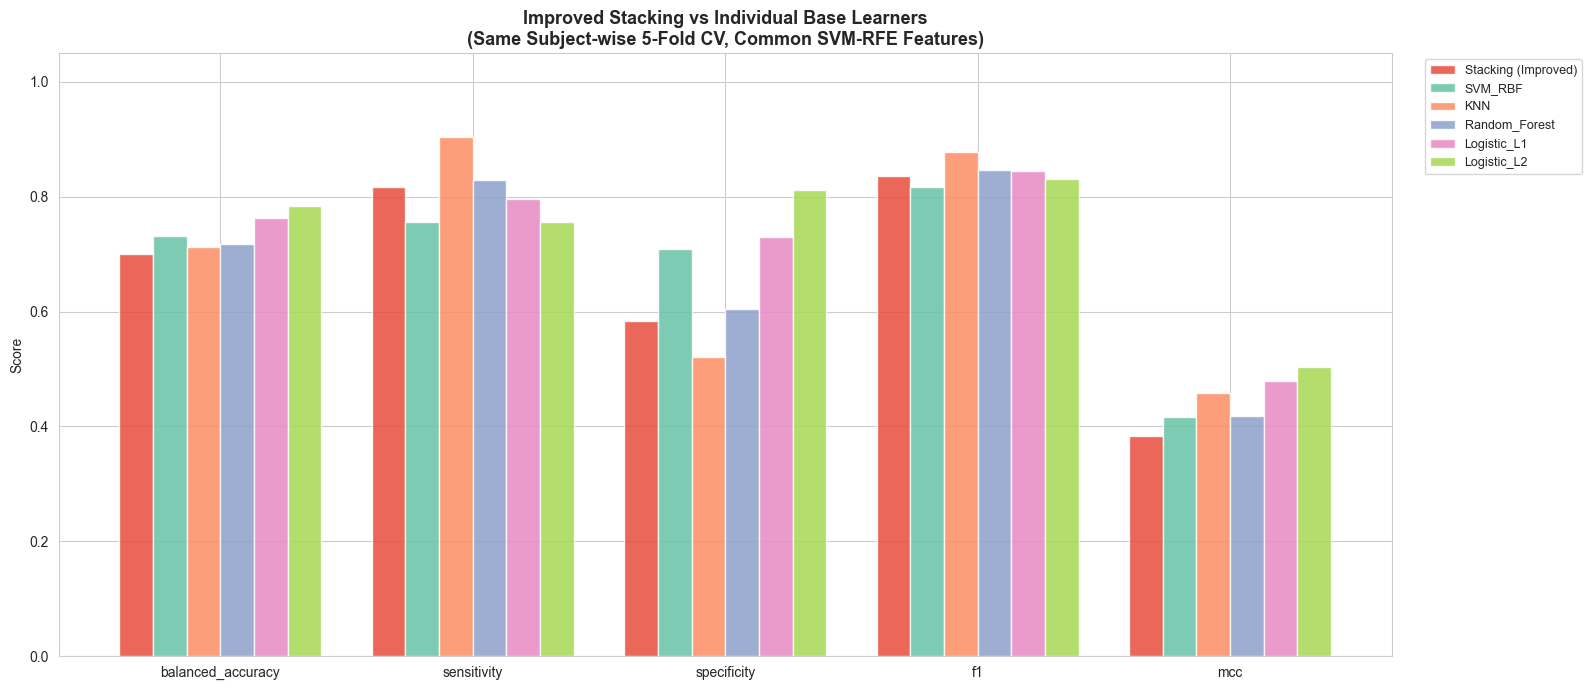

In [10]:
# Visualize comparison
metrics_to_plot = ['balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'mcc']
models_to_plot = ['Stacking (Improved)'] + list(BASE_LEARNERS.keys())

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(metrics_to_plot))
n_models = len(models_to_plot)
width = 0.8 / n_models

colors = ['#e74c3c'] + list(sns.color_palette('Set2', n_models - 1))

for i, model_name in enumerate(models_to_plot):
    vals = [comp_df.loc[model_name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=model_name, color=colors[i],
           alpha=0.85, edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Improved Stacking vs Individual Base Learners\n(Same Subject-wise 5-Fold CV, Common SVM-RFE Features)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../figures/improved_stacking_vs_individual.png', bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

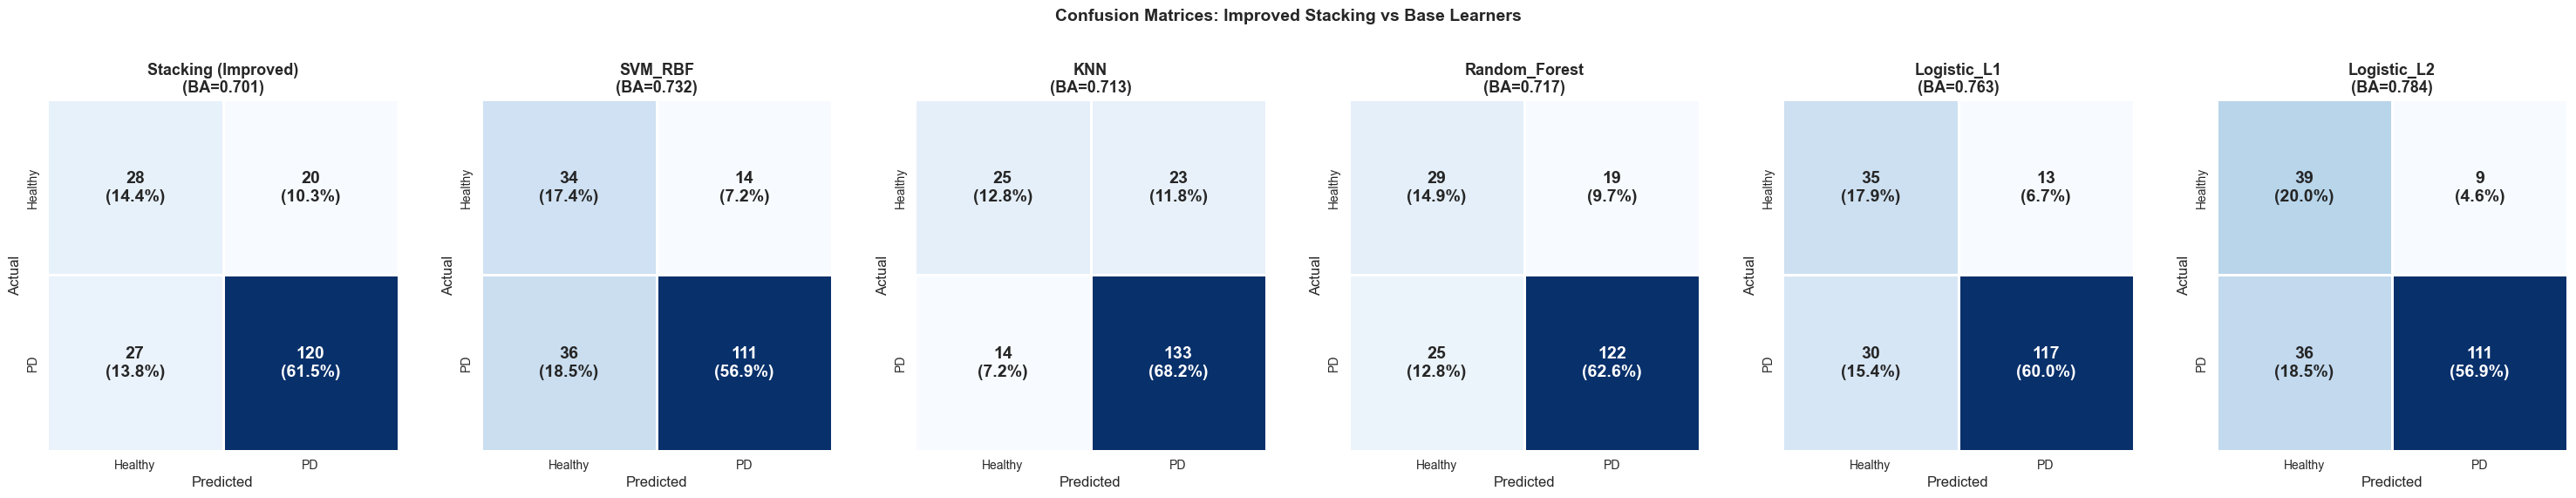

In [11]:
n_plots = 1 + len(BASE_LEARNERS)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

# Stacking first
ba_stack = stack_mean['balanced_accuracy']
plot_confusion_matrix(
    all_yt_stack, all_yp_stack,
    title=f'Stacking (Improved)\n(BA={ba_stack:.3f})',
    ax=axes[0]
)

# Individual base learners
for ax_idx, name in enumerate(BASE_LEARNERS.keys(), 1):
    all_yt = np.concatenate(base_y_trues[name])
    all_yp = np.concatenate(base_y_preds[name])
    ba = comparison[name]['balanced_accuracy']
    plot_confusion_matrix(all_yt, all_yp, title=f'{name}\n(BA={ba:.3f})', ax=axes[ax_idx])

plt.suptitle('Confusion Matrices: Improved Stacking vs Base Learners',
             fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig('../figures/improved_stacking_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 9. Ablation Study

In [12]:
ablation_results = {}

for remove_name in BASE_LEARNERS.keys():
    subset = {k: v for k, v in BASE_LEARNERS.items() if k != remove_name}
    
    outer_cv = GroupKFold(n_splits=N_OUTER)
    abl_y_trues, abl_y_preds, abl_y_probs = [], [], []
    
    for train_idx, test_idx in outer_cv.split(X_common, y, groups):
        X_tr, X_te = X_common.iloc[train_idx], X_common.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        groups_tr = groups.iloc[train_idx]
        
        # OOF predictions
        meta_X_tr, meta_y_tr, _ = generate_enriched_oof(
            subset, X_tr, y_tr, groups_tr, n_splits=N_INNER
        )
        
        # Train meta-learner
        meta = clone(META_LEARNER)
        meta.fit(meta_X_tr, meta_y_tr)
        
        # Test meta-features
        meta_X_te, _ = train_and_predict_enriched(subset, X_tr, y_tr, X_te)
        
        abl_y_trues.append(y_te.values)
        abl_y_preds.append(meta.predict(meta_X_te))
        try:
            abl_y_probs.append(meta.predict_proba(meta_X_te)[:, 1])
        except:
            abl_y_probs.append(None)
    
    all_yt = np.concatenate(abl_y_trues)
    all_yp = np.concatenate(abl_y_preds)
    all_yprob = np.concatenate([p for p in abl_y_probs if p is not None]) if abl_y_probs[0] is not None else None
    ablation_results[f'Without {remove_name}'] = compute_metrics(all_yt, all_yp, all_yprob)

# Full stacking
ablation_results['Full Stacking (5 models)'] = compute_metrics(all_yt_stack, all_yp_stack, all_yprob_stack)

ablation_df = results_to_dataframe(ablation_results)
print('--- Ablation Study: Impact of Removing Each Base Learner ---\n')
print(ablation_df.to_string())

--- Ablation Study: Impact of Removing Each Base Learner ---

                          accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                              
Without SVM_RBF             0.7692             0.7136       0.8231       0.6042     0.8643  0.8432  0.4090   0.7925
Without KNN                 0.7795             0.7625       0.7959       0.7292     0.9000  0.8448  0.4798   0.8248
Without Random_Forest       0.7385             0.6792       0.7959       0.5625     0.8478  0.8211  0.3395   0.8007
Without Logistic_L1         0.7436             0.6966       0.7891       0.6042     0.8593  0.8227  0.3671   0.7914
Without Logistic_L2         0.7538             0.6894       0.8163       0.5625     0.8511  0.8333  0.3647   0.7684
Full Stacking (5 models)    0.7590             0.6998       0.8163       0.5833     0.8571  0.8362  0.3826   0.7868


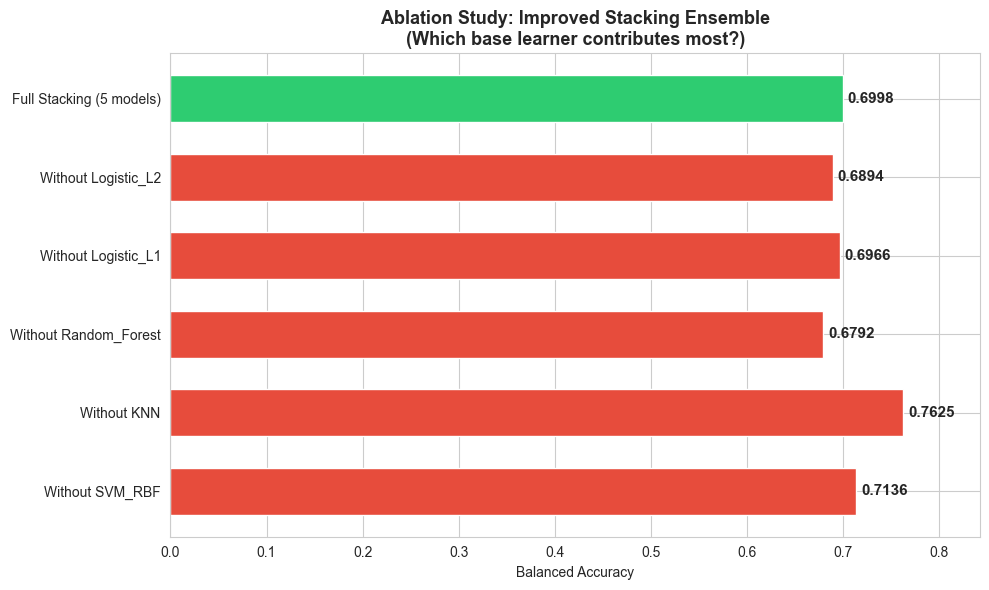


Contribution of each base learner (drop in BA when removed):
  Removing SVM_RBF: BA 0.6998 -> 0.7136 (-0.0138) — HELPS ensemble
  Removing KNN: BA 0.6998 -> 0.7625 (-0.0627) — HELPS ensemble
  Removing Random_Forest: BA 0.6998 -> 0.6792 (+0.0206) — HURTS ensemble
  Removing Logistic_L1: BA 0.6998 -> 0.6966 (+0.0032) — HURTS ensemble
  Removing Logistic_L2: BA 0.6998 -> 0.6894 (+0.0104) — HURTS ensemble


In [13]:
# Visualize ablation
fig, ax = plt.subplots(figsize=(10, 6))

abl_models = list(ablation_df.index)
ba_vals = ablation_df['balanced_accuracy'].values
colors = ['#2ecc71' if 'Full' in m else '#e74c3c' for m in abl_models]

bars = ax.barh(abl_models, ba_vals, color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Balanced Accuracy')
ax.set_title('Ablation Study: Improved Stacking Ensemble\n(Which base learner contributes most?)',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, ba_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, max(ba_vals) + 0.08)
plt.tight_layout()
plt.savefig('../figures/improved_stacking_ablation.png', bbox_inches='tight')
plt.show()

# Contribution summary
full_ba = ablation_results['Full Stacking (5 models)']['balanced_accuracy']
print('\nContribution of each base learner (drop in BA when removed):')
for name in BASE_LEARNERS:
    removed_ba = ablation_results[f'Without {name}']['balanced_accuracy']
    drop = full_ba - removed_ba
    direction = 'HURTS ensemble' if drop > 0 else 'HELPS ensemble' if drop < 0 else 'NEUTRAL'
    print(f'  Removing {name}: BA {full_ba:.4f} -> {removed_ba:.4f} ({drop:+.4f}) — {direction}')

## 10. Save Results

In [14]:
# Save improved stacking results
stack_results_dict = {
    'metric': list(stack_mean.index),
    'mean': list(stack_mean.values),
    'std': list(stack_std.values)
}
pd.DataFrame(stack_results_dict).to_csv('../results/improved_stacking_results.csv', index=False)

comp_df.to_csv('../results/improved_stacking_vs_individual.csv')
ablation_df.to_csv('../results/improved_stacking_ablation.csv')
weights_df.to_csv('../results/improved_meta_learner_weights.csv')

print('Saved to results/:')
print('  improved_stacking_results.csv')
print('  improved_stacking_vs_individual.csv')
print('  improved_stacking_ablation.csv')
print('  improved_meta_learner_weights.csv')

Saved to results/:
  improved_stacking_results.csv
  improved_stacking_vs_individual.csv
  improved_stacking_ablation.csv
  improved_meta_learner_weights.csv


## 11. Key Takeaways

Fill in after running:

### Improved Stacking Results
1. **Balanced accuracy**: ___ ± ___ (vs original stacking: 0.6579 ± 0.2134)
2. **Sensitivity / Specificity**: ___ / ___ (vs original: 0.932 / 0.383)
3. **Per-fold variance**: Did enriched meta-features reduce fold variance?

### Comparison
4. **vs Original stacking**: Did the improvements help?
5. **vs Best individual model (Logistic_L2 NB04: 0.7558)**: Does stacking now beat it?
6. **Meta-learner weights**: Which base learners and feature types does it rely on most?

### Ablation
7. **Most important base learner**: ___
8. **Least important base learner**: ___

### Final Verdict
9. Is stacking worth the complexity over the best individual model for this dataset?

**Next step**: Notebook 06 — Final Results Compilation